# Case 1: Observational Causal Modeling: Activity and Blood Pressure

## Set-up

Imagine you want to give high-quality, data-driven advice to individuals about their activity levels.

You have access to a relatively large retrospective dataset that includes information on

- Detailed dietary intake,
- Physical activity measures,
- Demographics and socioeconomic characteristics,
- Health outcomes such as blood pressure and BMI.

The data are stored in a file named "food-health.csv" (The second code block below downloads this data directly from dropbox.) The associated data dictionary is provided in "data_dictionary.pdata."

---

Suppose you are specifically interested in providing advice around the number of days per week that individuals participate in vigorous physical activity,

    sport_days

and how this relates to systolic blood pressure,

    bp_systolic

You begin by estimating the regression


$$\text{bp\_systolic}_i = \alpha + \beta \cdot \text{sport\_days}_i + \varepsilon_i$$


to understand the association between vigorous activity and systolic blood pressure.

Let's start there.

In [1]:
# Libraries
import pandas as pd
import numpy as np
import statsmodels.api as sm

In [2]:
# Get data from dropbox
# Import data from dropbox
# !wget -O food_health.csv "https://www.dropbox.com/scl/fi/a3jpecmxq1i9tkdesjwtp/food_health.csv?rlkey=ylj48ghu4lvxi89lvupn8k2xn&dl=0"

# Import
data = pd.read_csv("food_health.csv")
print(data.head())

   gr_skim_milk  gr_whole_milk  gr_soy_milk  gr_almond_milk  \
0           0.0           0.00          0.0             0.0   
1           0.0           0.00          0.0             0.0   
2           0.0         533.75          0.0             0.0   
3           0.0           0.00          0.0             0.0   
4           0.0           0.00          0.0             0.0   

   gr_chocolate_milk  gr_yogurt  gr_yogurt_low_fat  gr_greek_yogurt  \
0                0.0        0.0               0.00              0.0   
1                0.0        0.0               0.00              0.0   
2                0.0        0.0               0.00              0.0   
3                0.0        0.0             323.38              0.0   
4                0.0        0.0               0.00              0.0   

   gr_greek_yogurt_low_fat  gr_cream  ...  bp_diastolic  total_cholesterol  \
0                      0.0       0.0  ...          88.0               50.0   
1                      0.0       0.0  

In [3]:
# Summary statistics for two baseline variables
print(data[['bp_systolic', 'sport_days']].describe())

# Need to clean out invalid values (sport_days = 99)
data = data[data['sport_days'] < 99]

# There are also missing values in bp_systolic
# The count is less than the total sample size
data = data[~data['bp_systolic'].isna()]

# Let's check
print('\n')
print(data[['bp_systolic', 'sport_days']].describe())

        bp_systolic    sport_days
count  15345.000000  16484.000000
mean     122.982731      0.732286
std       18.180223      1.741562
min       85.000000      0.000000
25%      110.000000      0.000000
50%      120.000000      0.000000
75%      132.000000      0.000000
max      200.000000     99.000000


        bp_systolic    sport_days
count  15344.000000  15344.000000
mean     122.983055      0.735271
std       18.180770      1.569122
min       85.000000      0.000000
25%      110.000000      0.000000
50%      120.000000      0.000000
75%      132.000000      0.000000
max      200.000000      7.000000


In [4]:
# Simple regression
X = sm.add_constant(data['sport_days'])
y = data['bp_systolic']

model = sm.OLS(y, X).fit(cov_type='HC3')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            bp_systolic   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                     369.8
Date:                Mon, 11 May 2026   Prob (F-statistic):           1.90e-81
Time:                        03:04:25   Log-Likelihood:                -66144.
No. Observations:               15344   AIC:                         1.323e+05
Df Residuals:                   15342   BIC:                         1.323e+05
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        124.0906      0.167    744.096      0.0

## Set-up Questions:

**Question 1.** What is the estimated coefficient on `sport_days`? What does it mean mechanically? Is the relationship between `sport_days` and `bp_systolic` statistically significant?

What does the coefficient estimate imply about whether you should recommend increasing vigorous exercise to individuals who wish to lower their systolic blood pressure? Explain.

(HINT: In responding, be sure to think about the fact that the data is observational. Individuals were not randomly assigned different exercise levels.)

**Question 2.** The last line in the regression output reads

> Standard Errors are heteroscedasticity robust (HC3).

Briefly explain what that means and why it is likely important if our goal is to take the statistical conclusion seriously.

(HINT: Any AI can answer this question. It is worth understanding.)

---

## Answers:

**Answer 1.** The estimated coefficient of `sports_days` is `-1.5063` ($\hat{\beta}_\text{sports days} = -1.5063$). It means that for every 1 unit increase in $\text{sports\_days}$, the point prediction for $\text{bp\_systolic}$ goes _down_ by $1.5063$. The confidence interval for `sports_days` is $(-1.660, \enspace -1.353)$ at $95\%$ confidence—not containing $0.0$. Therefore, we conclude that the relationship between `sports_day` and `bp_systolic` is statistically significant.

However, this correlation says _nothing_ on whether vigorous exercise should (or should not) be recommended for lowering one's systolic blood pressure (i.e., **causality**). To determine causality, we have to hold an assumption about the data, _that's outside of the data itself_. In other words, you must assume unconfoundedness: 

> **After accounting on other observed set of characteristics** $X$, a person exercising 4 days/week would have a lower blood pressure compared to if they exercised 0 days/week.

You need to argue that you've removed all such $X$-es (confounders), usually using domain knowledge and/or experiment design.

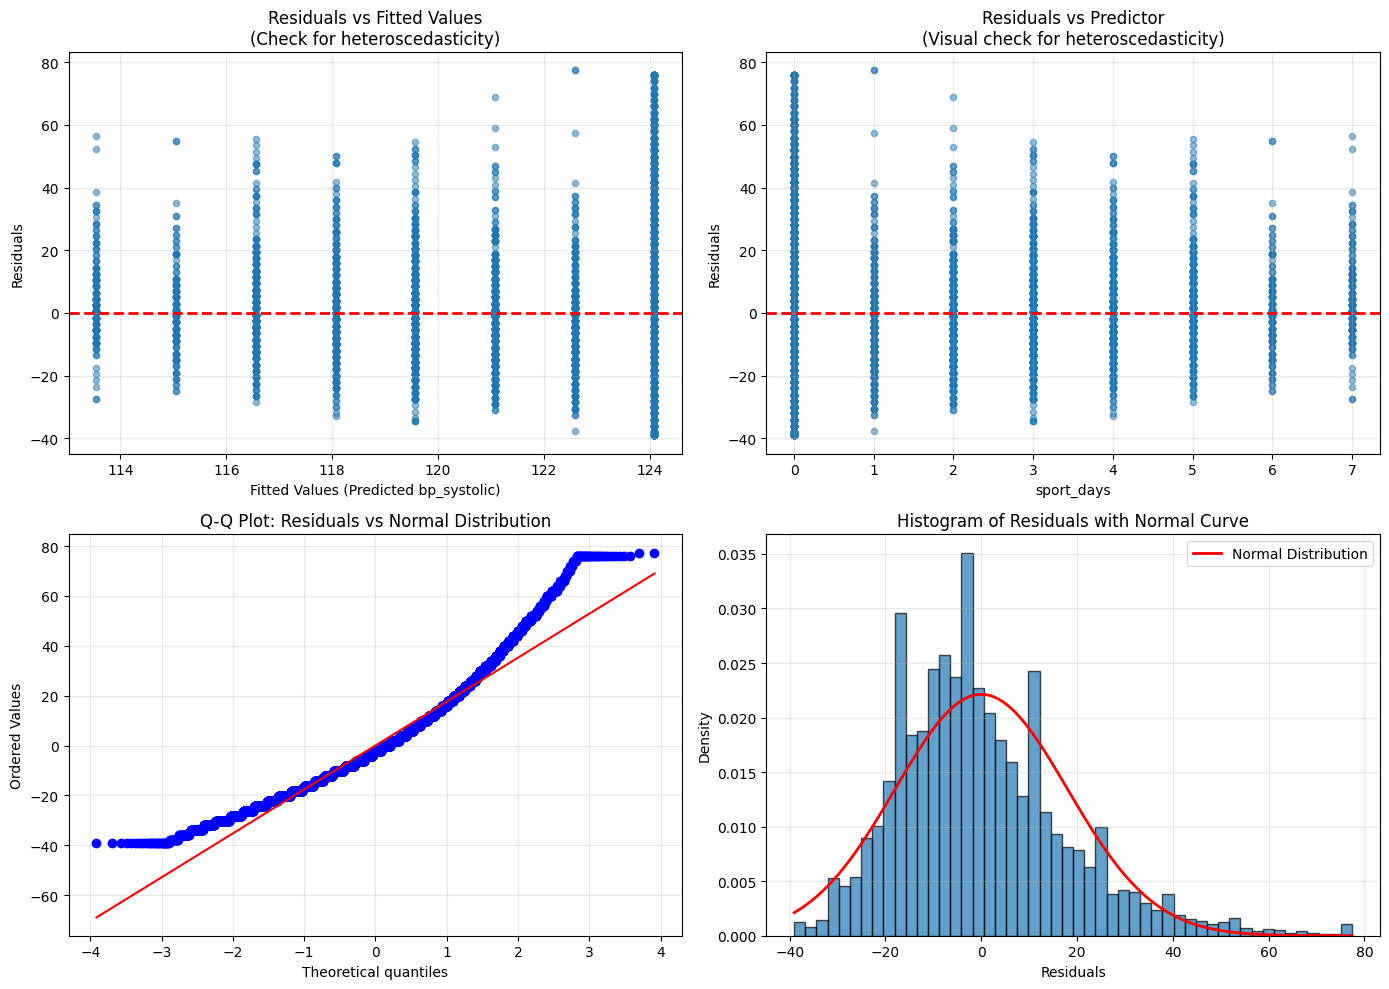


Residual variance by sport_days:
  sport_days = 0: variance = 357.17, n = 11895
  sport_days = 1: variance = 220.26, n = 509
  sport_days = 2: variance = 202.58, n = 699
  sport_days = 3: variance = 206.89, n = 914
  sport_days = 4: variance = 209.91, n = 517
  sport_days = 5: variance = 209.60, n = 472
  sport_days = 6: variance = 191.21, n = 161
  sport_days = 7: variance = 179.93, n = 177


In [5]:
import matplotlib.pyplot as plt
from scipy import stats

# Define fitted_values and residuals
fitted_values = model.predict(X)
residuals = y - fitted_values

# Create figure with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Residuals vs Fitted Values
axes[0, 0].scatter(fitted_values, residuals, alpha=0.5, s=20)
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Fitted Values (Predicted bp_systolic)')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Fitted Values\n(Check for heteroscedasticity)')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Residuals vs sport_days (predictor)
axes[0, 1].scatter(data['sport_days'], residuals, alpha=0.5, s=20)
axes[0, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('sport_days')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('Residuals vs Predictor\n(Visual check for heteroscedasticity)')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: QQ plot
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot: Residuals vs Normal Distribution')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Histogram of residuals with normal curve overlay
axes[1, 1].hist(residuals, bins=50, density=True, alpha=0.7, edgecolor='black')
mu, sigma = residuals.mean(), residuals.std()
x = np.linspace(residuals.min(), residuals.max(), 100)
axes[1, 1].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normal Distribution')
axes[1, 1].set_xlabel('Residuals')
axes[1, 1].set_ylabel('Density')
axes[1, 1].set_title('Histogram of Residuals with Normal Curve')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print variance of residuals by exercise level
print("\nResidual variance by sport_days:")
for days in sorted(data['sport_days'].unique()):
    resid_subset = residuals[data['sport_days'] == days]
    print(f"  sport_days = {days}: variance = {resid_subset.var():.2f}, n = {len(resid_subset)}")

**Answer 2.** The statement means that the dataset contains heteroskedastic residuals: the residual plot shows a "fanning pattern" demonstrating significant change in variance of `bp_systolic` given `sport_days` $\left(\sigma^2(\text{bp\_systolic} \mid \text{sport\_days})\right)$.

In this case, the `sport_days == 0` group have a larger `bp_systolic` variations, compared to groups with higher `sport_days` value.

The reported coefficient $\hat{\beta}_{\text{sport\_days}} = -1.5063$ with 95% CI $(-1.660, -1.353)$ is trustworthy because the `HC3` accounts for this heteroscedasticity.

If heteroscedasticity is present but we used "ordinary" (_non_-heteroscedasticity robust) OLS standard errors, our confidence intervals and p-values are **invalid**:
- Where variance is relatively larger, our confidence intervals will be too narrow (false precision), or
- Where variance is relatively smaller, our confidence intervals would've been too wide (false conservatism).

## Main Question Prompt

Your goal is now to do the best you can, using these data, to understand the *causal* effect of vigorous activity (as measured by `sport_days`) on health outcomes. You may focus on `bp_systolic` or choose another outcome (or combination of outcomes). You should justify your choice.

Start by examining the available variables and postulating a directed acyclic graph (DAG) that would allow you to learn the causal effect of `sport_days` on your chosen outcome by conditioning on an appropriate subset of the observed variables.

You should provide a rational argument for why your proposed DAG is a sensible starting point. Your argument does not need to be watertight (it won't be, given the data you have), but it should be logically coherent. For example:

*   Do not condition on outcomes.
*   Justify any included arrows.
*   Justify why certain arrows are excluded.
*   Use sensible groupings of variables where appropriate (e.g., it is not necessary to include a separate node for every food item if you decide that "diet" can be treated as a grouped input).

---

**Question 3.** Provide a drawing of your DAG and explain the underlying rationale.

---

You should now use debiased machine learning (DML) to estimate a partially linear model coefficient in which your chosen outcome is the dependent variable and `sport_days` is the treatment variable, controlling for confounding variables as indicated by your DAG.

---

**Question 4.** Clean the data.

We resolved two data quality issues in our setup. Before estimating any further models, inspect any variables that you intend to use and resolve any issues that you find.

Carefully document everything you do at this stage (e.g. dropping observations, imputing missing variables, variable transformations).

If you do any imputations or transformations, be sure that you do so in a way that avoids data leakage that could contaminate the DML estimation procedure.

---

**Question 5.** Estimate the partially linear regression coefficient using DML.

DML involves building predictive models and cross-fitting. Explain:

* What models were considered.
* How cross-fitting folds were constructed.
* What your final models are
* Why you made these choices

Provide the final estimated effect, its standard error, and explain how to interpret the result.

---

**Question 6.** Finally, and most importantly, build an explanation that you could present to a group of clinicians.

Imagine the clinicians care about giving data-driven advice to patients but are uncomfortable with providing advice they don't understand or can't explain. That is, your explanation should

* Clearly state the conclusion.
* Describe the assumptions under which your estimates have a causal interpretation.
* Discuss important confounders (if any) identified in the prediction steps of DML.
* Highlight relevant caveats.

One natural caveat to address is *heterogeneity*: up to this point, the prompt has asked for a single summary effect. Be prepared to discuss whether the effect may differ across different (groups of) individuals and, if time permits, explore some potential sources of heterogeneity.

This part of the solution should be provided as a slide deck (and notes) suitable for a 10-minute presentation.

In [6]:
print("="*80)
print("AVAILABLE VARIABLES IN DATASET")
print("="*80)

data.info()
for i, col in enumerate(data.columns, 1):
    print(f"{i:3d}. {col}")

print(f"\nTotal variables: {len(data.columns)}")
print("="*80)

AVAILABLE VARIABLES IN DATASET
<class 'pandas.DataFrame'>
Index: 15344 entries, 0 to 16483
Columns: 656 entries, gr_skim_milk to heart_risk
dtypes: float64(342), int64(310), str(4)
memory usage: 76.9 MB
  1. gr_skim_milk
  2. gr_whole_milk
  3. gr_soy_milk
  4. gr_almond_milk
  5. gr_chocolate_milk
  6. gr_yogurt
  7. gr_yogurt_low_fat
  8. gr_greek_yogurt
  9. gr_greek_yogurt_low_fat
 10. gr_cream
 11. gr_cream_sub
 12. gr_sour_cream
 13. gr_ice_cream
 14. gr_light_ice_cream
 15. gr_white_sauces
 16. gr_cheese
 17. gr_cheese_low_fat
 18. gr_cheese_nonfat
 19. gr_cottage_cheese
 20. gr_cream_cheese
 21. gr_processed_cheese
 22. gr_beef
 23. gr_beef_lean
 24. gr_pork
 25. gr_pork_lean
 26. gr_lamb
 27. gr_lamb_lean
 28. gr_goat
 29. gr_chicken
 30. gr_turkey
 31. gr_duck
 32. gr_lunch_sandwich
 33. gr_sausage
 34. gr_cold_cuts
 35. gr_fish
 36. gr_other_seafood
 37. gr_crab
 38. gr_lobster
 39. gr_oysters
 40. gr_scallops
 41. gr_shrimp
 42. gr_beef_with_starch
 43. gr_pork_with_starch


In [7]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# LASSO EVALUATION: Predictor selection for bp_systolic
# =============================================================================
# Goal: identify which variables meaningfully predict bp_systolic
# before committing to a confounder set for DAG and DML.
# =============================================================================

# ---- 1. Build feature set ----------------------------------------

EXTRA_VARS = [
    'race',             # demographic
    'gender_female',    # demographic (encoded below)
    'married',          # socioeconomic
    'hh_income_percap', # income per household member (better than hh_income for BP)
    'walk_cycle_days',  # other physical activity (separates vigorous vs. moderate)
    'red_meat_all',     # diet: total red meat consumption
    'beef_all',         # additional diet: total beef consumption
    'nuts',             # diet: nuts (heart-healthy fat)
    'alcohol',          # diet: alcohol (dose-dependent BP effect)
    'veggies_gr',       # diet: vegetables (DASH diet)
    'fruits_gr',        # diet: fruits (potassium → BP)
    'bp_diastolic',     # baseline diastolic BP (strong predictor of systolic)
    'weight',           # body weight (more direct than BMI for BP prediction)
    'height',           # needed alongside weight; also inversely correlated with BP
    'bmi',              # body mass index (strong predictor of BP)
    'smoker',           # smoking status (binary)
    'sleep_hs',         # sleep hours (nonlinear effect on BP)
    'age',              # age (nonlinear effect on BP)
    'age2',             # age squared (nonlinear effect on BP)
    'age_smoker'       # interaction: smoking may have stronger effect in older adults
]

# Pull from original data (pre-cleaning)
data_lasso = data
data_lasso['gender_female'] = (data_lasso['gender'] == 'female').astype(float)
data_lasso['age_smoker'] = data_lasso['age'] * data_lasso['smoker']

lasso_vars = (
    ['bp_systolic', 'sport_days']
    + EXTRA_VARS
)

data_lasso = (
    data_lasso[lasso_vars]
    .dropna()
    # re-apply validity filters
    .loc[lambda d: (d['sport_days'] >= 0) & (d['sport_days'] <= 7)]
    .loc[lambda d: (d['bmi'] >= 12) & (d['bmi'] <= 60)]
    .loc[lambda d: (d['sleep_hs'] >= 0) & (d['sleep_hs'] <= 24)]
    .reset_index(drop=True)
)

print(data_lasso.head())

   bp_systolic  sport_days  race  gender_female  married  hh_income_percap  \
0        114.0           0     3            0.0        1          7500.000   
1        154.0           0     4            1.0        0          6250.000   
2        102.0           2     1            0.0        1          6000.000   
3        118.0           0     3            1.0        1         13333.333   
4        142.0           0     3            0.0        1          8750.000   

   walk_cycle_days  red_meat_all  beef_all  nuts  ...  fruits_gr  \
0                0             0         0     0  ...     505.16   
1                0             1         1     0  ...       0.00   
2                7             0         0     0  ...       0.00   
3                0             1         0     0  ...     291.00   
4                7             3         1     0  ...     166.00   

   bp_diastolic      weight     height        bmi  smoker  sleep_hs  age  \
0          88.0   87.400002  164.70000  32.219

In [8]:

print(data_lasso.describe())

        bp_systolic    sport_days          race  gender_female       married  \
count  14955.000000  14955.000000  14955.000000   14955.000000  14955.000000   
mean     122.918689      0.742427      3.050084       0.504982      0.556670   
std       18.118130      1.575352      1.156634       0.499992      0.496795   
min       85.000000      0.000000      1.000000       0.000000      0.000000   
25%      110.000000      0.000000      3.000000       0.000000      0.000000   
50%      120.000000      0.000000      3.000000       1.000000      1.000000   
75%      132.000000      0.000000      4.000000       1.000000      1.000000   
max      200.000000      7.000000      5.000000       1.000000      1.000000   

       hh_income_percap  walk_cycle_days  red_meat_all      beef_all  \
count      14955.000000     14955.000000  14955.000000  14955.000000   
mean       21329.925495         1.379539      0.662721      0.461518   
std        20827.365465         2.422474      0.754584      0.6

LASSO dataset: 14,955 obs, 21 features
Features: ['sport_days', 'race', 'gender_female', 'married', 'hh_income_percap', 'walk_cycle_days', 'red_meat_all', 'beef_all', 'nuts', 'alcohol', 'veggies_gr', 'fruits_gr', 'bp_diastolic', 'weight', 'height', 'bmi', 'smoker', 'sleep_hs', 'age', 'age2', 'age_smoker']

LASSO RESULTS  (outcome: bp_systolic, standardized coefficients)
Optimal alpha (lambda):   0.008544
Variables retained:       20 / 21
R² on training data:      0.4035
----------------------------------------------------------------------
         Feature  Coefficient (std.)  Retained
            age2           19.489516      True
             age          -10.983192      True
    bp_diastolic            7.487435      True
   gender_female           -1.877643      True
          height           -1.735810      True
          weight            1.386763      True
hh_income_percap           -0.930084      True
         married           -0.632867      True
            nuts           -0.5

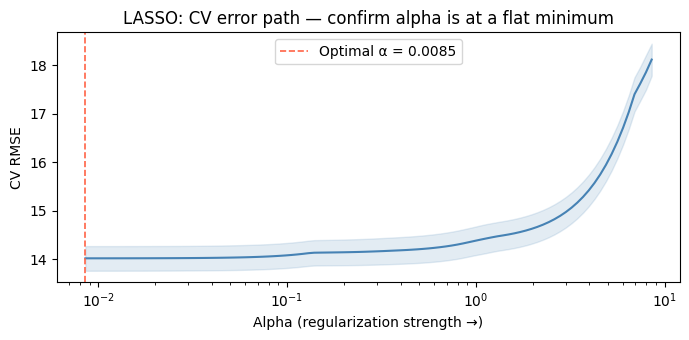

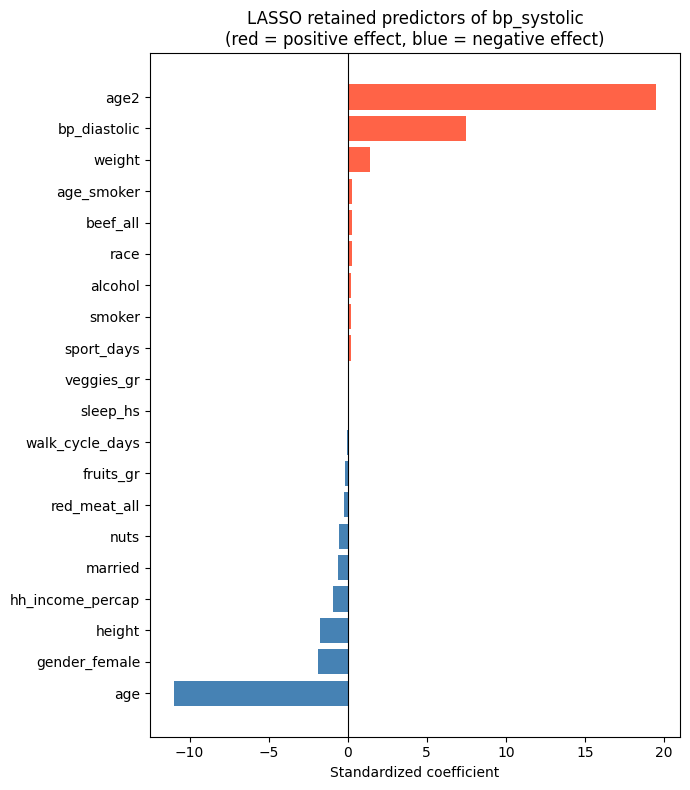


--- VARIABLE SELECTION GUIDANCE ---

Strong predictors (|coef| >= 0.5):  ['age2', 'age', 'bp_diastolic', 'gender_female', 'height', 'weight', 'hh_income_percap', 'married', 'nuts']
  → Include in DML confounder set.

Weak but retained (|coef| < 0.5): ['age_smoker', 'beef_all', 'race', 'red_meat_all', 'alcohol', 'smoker', 'sport_days', 'fruits_gr', 'veggies_gr', 'walk_cycle_days', 'sleep_hs']
  → Evaluate individually. Include if theoretically motivated;
    their LASSO weight is small but nonzero.

Zeroed out by LASSO: ['bmi']
  → Low predictive value for bp_systolic. Consider dropping,
    unless there is a strong causal reason to keep them.

--- R² COMPARISON ---
  OLS (7 vars, your current model): R² ≈ 0.231
  LASSO (expanded, 21 features):          R² = 0.403
  Gain from expansion: +0.172

  A large gain means your current confounder set was underfitting.
  Add the strong predictors above to the DML nuisance models.


In [9]:
# ---- 2. Feature engineering ------------------------------------------------
FEATURES = [c for c in data_lasso.columns if c != 'bp_systolic']

print(f"LASSO dataset: {data_lasso.shape[0]:,} obs, {len(FEATURES)} features")
print(f"Features: {FEATURES}")

# ---- 3. Scale features (required for LASSO) --------------------------------
# Scale BEFORE LassoCV. Because we are using this only for variable selection
# (not to produce final DML residuals), fitting the scaler on all data here
# is fine — there is no data leakage into a DML prediction step.
scaler = StandardScaler()
X_lasso = scaler.fit_transform(data_lasso[FEATURES])
y_lasso = data_lasso['bp_systolic'].values

# ---- 4. LassoCV: cross-validated regularization path ----------------------
# alphas=None uses sklearn's default log-spaced grid (100 alphas).
# 5-fold CV balances variance and cost.
lasso_cv = LassoCV(
    cv=5,
    random_state=42,
    max_iter=5000,
    n_alphas=100,
)
lasso_cv.fit(X_lasso, y_lasso)

# ---- 5. Results table -------------------------------------------------------
coef_df = (
    pd.DataFrame({
        'Feature': FEATURES,
        'Coefficient (std.)': lasso_cv.coef_,
        'Abs': np.abs(lasso_cv.coef_),
        'Retained': lasso_cv.coef_ != 0,
    })
    .sort_values('Abs', ascending=False)
    .reset_index(drop=True)
)

print("\n" + "="*70)
print("LASSO RESULTS  (outcome: bp_systolic, standardized coefficients)")
print("="*70)
print(f"Optimal alpha (lambda):   {lasso_cv.alpha_:.6f}")
print(f"Variables retained:       {coef_df['Retained'].sum()} / {len(FEATURES)}")
print(f"R² on training data:      {lasso_cv.score(X_lasso, y_lasso):.4f}")
print("-"*70)
print(coef_df[['Feature', 'Coefficient (std.)', 'Retained']].to_string(index=False))
print("="*70)

# ---- 6. CV error curve (optional visual check) ------------------------------
# Helps verify the selected alpha is at a stable minimum, not a cliff edge.
cv_mean  = lasso_cv.mse_path_.mean(axis=1)
cv_std   = lasso_cv.mse_path_.std(axis=1)
best_idx = np.where(lasso_cv.alphas_ == lasso_cv.alpha_)[0][0]

plt.figure(figsize=(7, 3.5))
plt.semilogx(lasso_cv.alphas_, np.sqrt(cv_mean), color='steelblue', lw=1.5)
plt.fill_between(
    lasso_cv.alphas_,
    np.sqrt(cv_mean - cv_std),
    np.sqrt(cv_mean + cv_std),
    alpha=0.15, color='steelblue'
)
plt.axvline(lasso_cv.alpha_, color='tomato', linestyle='--', lw=1.2,
            label=f"Optimal α = {lasso_cv.alpha_:.4f}")
plt.xlabel("Alpha (regularization strength →)")
plt.ylabel("CV RMSE")
plt.title("LASSO: CV error path — confirm alpha is at a flat minimum")
plt.legend()
plt.tight_layout()
plt.savefig("lasso_cv_path.png", dpi=120, bbox_inches='tight')
plt.show()

# ---- 7. Coefficient bar chart -----------------------------------------------
retained = coef_df[coef_df['Retained']].sort_values('Coefficient (std.)')
colors   = ['tomato' if c > 0 else 'steelblue'
            for c in retained['Coefficient (std.)']]

plt.figure(figsize=(7, max(3.5, 0.4 * len(retained))))
plt.barh(retained['Feature'], retained['Coefficient (std.)'],
         color=colors, edgecolor='none')
plt.axvline(0, color='black', lw=0.8)
plt.xlabel("Standardized coefficient")
plt.title("LASSO retained predictors of bp_systolic\n"
          "(red = positive effect, blue = negative effect)")
plt.tight_layout()
plt.savefig("lasso_coefficients.png", dpi=120, bbox_inches='tight')
plt.show()

# ---- 8. Model selection guidance -------------------------------------------
STRONG_THRESHOLD = 0.5   # |coef| in std. units; adjust if needed
strong = coef_df[coef_df['Abs'] >= STRONG_THRESHOLD]['Feature'].tolist()
weak   = coef_df[(coef_df['Retained']) & (coef_df['Abs'] < STRONG_THRESHOLD)]['Feature'].tolist()
zeroed = coef_df[~coef_df['Retained']]['Feature'].tolist()

print("\n--- VARIABLE SELECTION GUIDANCE ---")
print(f"\nStrong predictors (|coef| >= {STRONG_THRESHOLD}):  {strong}")
print(f"  → Include in DML confounder set.")
print(f"\nWeak but retained (|coef| < {STRONG_THRESHOLD}): {weak}")
print(f"  → Evaluate individually. Include if theoretically motivated;\n"
      f"    their LASSO weight is small but nonzero.")
print(f"\nZeroed out by LASSO: {zeroed}")
print(f"  → Low predictive value for bp_systolic. Consider dropping,\n"
      f"    unless there is a strong causal reason to keep them.")

# ---- 9. Compare: current OLS R² vs. LASSO R² --------------------------------
# Recall from earlier output: OLS (7 vars) R² ≈ 0.231.
# LASSO (expanded) R² tells you how much more signal the extra vars add.
print(f"\n--- R² COMPARISON ---")
print(f"  OLS (7 vars, your current model): R² ≈ 0.231")
print(f"  LASSO (expanded, {len(FEATURES)} features):          R² = {lasso_cv.score(X_lasso, y_lasso):.3f}")
print(f"  Gain from expansion: {lasso_cv.score(X_lasso, y_lasso) - 0.231:+.3f}")
print(f"\n  A large gain means your current confounder set was underfitting.")
print(f"  Add the strong predictors above to the DML nuisance models.")

### Feature Engineering Decisions

**Drop `bmi`, keep `weight` and `height` separately.**

BMI is defined as weight divided by height squared. Given both components are already in the model, BMI carries no independent information — LASSO correctly zeroes it out. Keeping `weight` and `height` separately also allows the model to capture their distinct physiological roles:

- `weight` → `bp_systolic`: greater body mass increases cardiac output demands, raising BP
- `height` → `bp_systolic`: taller individuals have lower BP on average, independent of weight, due to cardiovascular geometry

**One-hot encode `race`.**

Race is coded numerically 1–5 in this dataset (1 = Mexican American, 2 = Other Hispanic, 3 = Non-Hispanic White, 4 = Non-Hispanic Black, 5 = Other). Treating this as a continuous variable imposes a false ordering and linear spacing. Non-Hispanic Black individuals (code 4) have substantially higher hypertension prevalence — a pattern that cannot be represented by a single slope across an arbitrary numeric sequence. One-hot encoding lets each group have its own intercept shift.

**Keep `age` and `age²` together.**

The LASSO assigns the two largest coefficients in the model to these variables — and they must be interpreted jointly. The combination of a large positive `age²` and large negative `age` produces a J-shaped curve: BP rises slowly in young adults and accelerates sharply after roughly age 50. Dropping either term would reintroduce misspecification, pushing curvature into other coefficients.

**Drop `beef_all`, keep `red_meat_all`.**

Both variables are retained by LASSO but with opposite signs (+0.25 and −0.23), which is a multicollinearity artifact — they measure overlapping content and LASSO is splitting the signal arbitrarily between them. `red_meat_all` is the broader and more theoretically motivated measure:

- `red_meat_all` → `bp_systolic`: red meat consumption raises BP through sodium, saturated fat, and heme iron pathways
- `red_meat_all` → `bmi` → `bp_systolic`: high red meat diets are associated with weight gain, which raises BP indirectly

**Keep `veggies_gr`, `walk_cycle_days`, and `sleep_hs` despite near-zero LASSO weights.**

LASSO shrinks these to near zero but does not zero them out, meaning they retain marginal predictive signal after all other variables are accounted for. More importantly, all three appear in the DAG for theoretical reasons and their exclusion would leave open confounding paths:

- `hh_income` → `sleep_hs` → `bp_systolic`: wealthier individuals sleep more and have lower BP; this path runs through sleep independently of diet or smoking
- `hh_income` → `veggies_gr` → `bp_systolic`: diet quality varies with income and affects BP through potassium and fiber intake
- `walk_cycle_days` → `bp_systolic`: moderate physical activity lowers BP through similar pathways as vigorous activity; failing to condition on it would conflate the effect of vigorous exercise with general physical activity patterns

---

### DAG

The DAG below reflects the final confounder set after feature engineering. Nodes in the graph correspond exactly to variables entering the DML model.

**Root confounder: household income**

Household income propagates confounding through almost every pathway:

- `hh_income_percap` → `sport_days`: wealthier people have time, money, and safe neighborhoods to exercise
- `hh_income_percap` → `red_meat_all`: diet quality varies with income
- `hh_income_percap` → `smoker`: smoking is more prevalent at lower incomes
- `hh_income_percap` → `sleep_hs`: wealthier individuals face less stress and have better housing conditions
- `hh_income_percap` → `veggies_gr`: higher income enables more varied, plant-rich diets
- `hh_income_percap` → `bp_systolic`: direct effect via healthcare access and chronic stress

**Demographic confounders**

- `age` and `age²` → `sport_days`: physical capacity declines with age, reducing exercise participation
- `age` and `age²` → `bp_systolic`: BP rises nonlinearly with age due to arterial stiffening
- `gender_female` → `sport_days`: activity patterns differ by sex
- `gender_female` → `bp_systolic`: women have lower BP on average prior to menopause
- `race` → `sport_days`: structural barriers to exercise vary across racial groups
- `race` → `bp_systolic`: prevalence of hypertension differs substantially by race, particularly elevated in Non-Hispanic Black individuals
- `married` → `sport_days`: partnered individuals may exercise more through social motivation
- `married` → `bp_systolic`: social support is associated with lower cardiovascular risk

**Body composition**

- `weight` → `bp_systolic`: higher body mass increases cardiac demands
- `height` → `bp_systolic`: taller individuals tend to have lower BP independent of weight
- `weight` and `height` are downstream of `hh_income_percap`, `red_meat_all`, and `sport_days` — they sit on both confounding and mediating paths. We include them as pre-treatment baseline measures of body composition, not as mediators of the exercise effect.

**Baseline cardiovascular status**

- `bp_diastolic` → `bp_systolic`: diastolic and systolic pressure share common drivers (arterial stiffness, vascular resistance). Including diastolic BP controls for a person's baseline cardiovascular condition before any effect of exercise is attributed.

**Lifestyle**

- `smoker` → `bp_systolic`: nicotine causes acute and chronic BP elevation through sympathetic activation
- `age_smoker` (interaction): the cardiovascular damage from smoking accumulates over time, so the smoking effect on BP intensifies with age
- `sleep_hs` → `bp_systolic`: poor sleep activates the sympathetic nervous system and raises BP
- `walk_cycle_days` → `bp_systolic`: moderate physical activity lowers BP through vascular adaptation, partially overlapping with the vigorous activity pathway

**Mediating paths (total effect estimation)**

These are causal pathways from `sport_days` to `bp_systolic` — we do not condition on them:

- `sport_days` → `weight` → `bp_systolic`: exercise reduces body mass, which lowers BP
- `sport_days` → `bp_systolic`: direct effect via improved cardiac efficiency and vascular tone

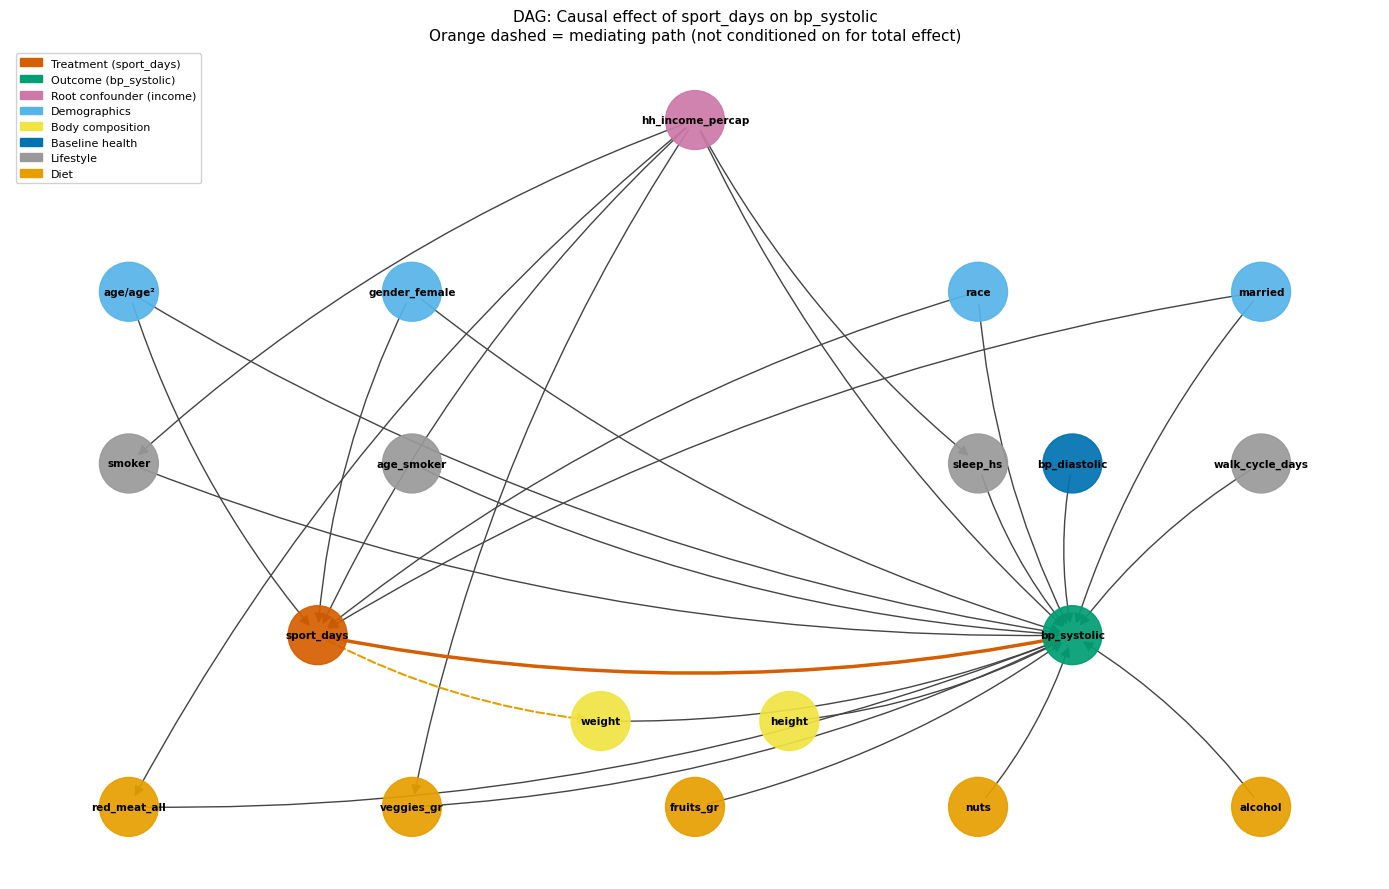

In [10]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

G = nx.DiGraph()

# Node groups
treatment  = ['sport_days']
outcome    = ['bp_systolic']
income     = ['hh_income_percap']
demo       = ['age/age²', 'gender_female', 'race', 'married']
body       = ['weight', 'height']
health     = ['bp_diastolic']
lifestyle  = ['smoker', 'age_smoker', 'sleep_hs', 'walk_cycle_days']
diet       = ['red_meat_all', 'veggies_gr', 'fruits_gr', 'nuts', 'alcohol']

all_nodes = treatment + outcome + income + demo + body + health + lifestyle + diet
G.add_nodes_from(all_nodes)

edges = [
    # Income → everything
    ('hh_income_percap', 'sport_days'),
    ('hh_income_percap', 'red_meat_all'),
    ('hh_income_percap', 'smoker'),
    ('hh_income_percap', 'sleep_hs'),
    ('hh_income_percap', 'veggies_gr'),
    ('hh_income_percap', 'bp_systolic'),
    # Demographics → treatment & outcome
    ('age/age²',     'sport_days'),
    ('age/age²',     'bp_systolic'),
    ('gender_female','sport_days'),
    ('gender_female','bp_systolic'),
    ('race',         'sport_days'),
    ('race',         'bp_systolic'),
    ('married',      'sport_days'),
    ('married',      'bp_systolic'),
    # Body composition → outcome
    ('weight',       'bp_systolic'),
    ('height',       'bp_systolic'),
    # Baseline health → outcome
    ('bp_diastolic', 'bp_systolic'),
    # Lifestyle → outcome
    ('smoker',       'bp_systolic'),
    ('age_smoker',   'bp_systolic'),
    ('sleep_hs',     'bp_systolic'),
    ('walk_cycle_days', 'bp_systolic'),
    # Diet → outcome
    ('red_meat_all', 'bp_systolic'),
    ('veggies_gr',   'bp_systolic'),
    ('fruits_gr',    'bp_systolic'),
    ('nuts',         'bp_systolic'),
    ('alcohol',      'bp_systolic'),
    # Treatment → outcome (causal effect of interest)
    ('sport_days',   'bp_systolic'),
    # Mediating paths (sport_days → weight → bp_systolic)
    ('sport_days',   'weight'),
]

G.add_edges_from(edges)

# Layout: manual positions for readability
pos = {
    'hh_income_percap': (0,    3),
    'age/age²':         (-3,   2),
    'gender_female':    (-1.5, 2),
    'race':             (1.5,  2),
    'married':          (3,    2),
    'sport_days':       (-2,   0),
    'bp_systolic':      (2,    0),
    'red_meat_all':     (-3,  -1),
    'veggies_gr':       (-1.5,-1),
    'fruits_gr':        (0,   -1),
    'nuts':             (1.5, -1),
    'alcohol':          (3,   -1),
    'smoker':           (-3,   1),
    'age_smoker':       (-1.5, 1),
    'sleep_hs':         (1.5,  1),
    'walk_cycle_days':  (3,    1),
    'weight':           (-0.5, -0.5),
    'height':           (0.5,  -0.5),
    'bp_diastolic':     (2,    1),
}

color_map = {
    n: '#D55E00' if n in treatment  else
       '#009E73' if n in outcome    else
       '#CC79A7' if n in income     else
       '#56B4E9' if n in demo       else
       '#F0E442' if n in body       else
       '#0072B2' if n in health     else
       '#999999' if n in lifestyle  else
       '#E69F00'                          # diet
    for n in G.nodes()
}
node_colors = [color_map[n] for n in G.nodes()]

fig, ax = plt.subplots(figsize=(14, 9))

nx.draw_networkx_nodes(G, pos, node_color=node_colors,
                       node_size=1800, ax=ax, alpha=0.92)
nx.draw_networkx_labels(G, pos, font_size=7.5, font_weight='bold', ax=ax)

# Causal edge (treatment → outcome) in red; mediating in dashed orange; rest in gray
causal_edge    = [('sport_days', 'bp_systolic')]
mediating_edge = [('sport_days', 'weight')]
other_edges    = [e for e in G.edges()
                  if e not in causal_edge and e not in mediating_edge]

nx.draw_networkx_edges(G, pos, edgelist=other_edges,
                       edge_color='#444444', arrows=True,
                       arrowsize=15, width=1.0,
                       connectionstyle='arc3,rad=0.1', ax=ax)
nx.draw_networkx_edges(G, pos, edgelist=causal_edge,
                       edge_color='#D55E00', arrows=True,
                       arrowsize=20, width=2.5,
                       connectionstyle='arc3,rad=0.1', ax=ax)
nx.draw_networkx_edges(G, pos, edgelist=mediating_edge,
                       edge_color='#E69F00', arrows=True,
                       arrowsize=15, width=1.5, style='dashed',
                       connectionstyle='arc3,rad=0.1', ax=ax)

legend_handles = [
    mpatches.Patch(color='#D55E00', label='Treatment (sport_days)'),
    mpatches.Patch(color='#009E73', label='Outcome (bp_systolic)'),
    mpatches.Patch(color='#CC79A7', label='Root confounder (income)'),
    mpatches.Patch(color='#56B4E9', label='Demographics'),
    mpatches.Patch(color='#F0E442', label='Body composition'),
    mpatches.Patch(color='#0072B2', label='Baseline health'),
    mpatches.Patch(color='#999999', label='Lifestyle'),
    mpatches.Patch(color='#E69F00', label='Diet'),
]
ax.legend(handles=legend_handles, loc='upper left', fontsize=8, framealpha=0.9)

ax.set_title('DAG: Causal effect of sport_days on bp_systolic\n'
             'Orange dashed = mediating path (not conditioned on for total effect)',
             fontsize=11)
ax.axis('off')
plt.tight_layout()
plt.show()

In [11]:
# Final clean-up

# 1. Winsorize fruits_gr (and check veggies_gr)
p99_fruits = data_lasso['fruits_gr'].quantile(0.99)
p99_veggies = data_lasso['veggies_gr'].quantile(0.99)
p99_alcohol = data_lasso['alcohol'].quantile(0.99)
print(f"alcohol 99th pct: {p99_alcohol:.1f}")
print(f"fruits_gr  99th pct: {p99_fruits:.1f}")
print(f"veggies_gr 99th pct: {p99_veggies:.1f}")
data_lasso['fruits_gr']  = data_lasso['fruits_gr'].clip(upper=p99_fruits)
data_lasso['veggies_gr'] = data_lasso['veggies_gr'].clip(upper=p99_veggies)
data_lasso['alcohol'] = data_lasso['alcohol'].clip(upper=p99_alcohol)

# 2. Log-transform income
data_lasso['ln_hh_income_percap'] = np.log(data_lasso['hh_income_percap'])
data_lasso = data_lasso.drop(columns=['hh_income_percap'])

# 3. One-hot encode race (drop numeric, add dummies, reference = Non-Hispanic White = 3)
race_dummies = pd.get_dummies(data_lasso['race'], prefix='race').drop(columns=['race_3'])
data_lasso = pd.concat([data_lasso.drop(columns=['race']), race_dummies], axis=1)

# 4. Drop bmi & beef
data_lasso = data_lasso.drop(columns=['beef_all'])
data_lasso = data_lasso.drop(columns=['bmi'])

alcohol 99th pct: 18.6
fruits_gr  99th pct: 811.5
veggies_gr 99th pct: 697.1


In [12]:
print(data_lasso.head())

   bp_systolic  sport_days  gender_female  married  walk_cycle_days  \
0        114.0           0            0.0        1                0   
1        154.0           0            1.0        0                0   
2        102.0           2            0.0        1                7   
3        118.0           0            1.0        1                0   
4        142.0           0            0.0        1                7   

   red_meat_all  nuts  alcohol  veggies_gr  fruits_gr  ...  smoker  sleep_hs  \
0             0     0      0.0    0.000000     505.16  ...       0       4.0   
1             1     0      0.0  218.190000       0.00  ...       1       4.0   
2             0     0      0.0   74.345001       0.00  ...       0       4.0   
3             1     0      0.0  262.500000     291.00  ...       1       8.0   
4             3     0      0.0   38.000000     166.00  ...       0       6.0   

   age  age2  age_smoker  ln_hh_income_percap  race_1  race_2  race_4  race_5  
0   34  1156

In [13]:
print(data_lasso.describe())

        bp_systolic    sport_days  gender_female       married  \
count  14955.000000  14955.000000   14955.000000  14955.000000   
mean     122.918689      0.742427       0.504982      0.556670   
std       18.118130      1.575352       0.499992      0.496795   
min       85.000000      0.000000       0.000000      0.000000   
25%      110.000000      0.000000       0.000000      0.000000   
50%      120.000000      0.000000       1.000000      1.000000   
75%      132.000000      0.000000       1.000000      1.000000   
max      200.000000      7.000000       1.000000      1.000000   

       walk_cycle_days  red_meat_all          nuts       alcohol  \
count     14955.000000  14955.000000  14955.000000  14955.000000   
mean          1.379539      0.662721      0.106520      0.263828   
std           2.422474      0.754584      0.336901      2.113344   
min           0.000000      0.000000      0.000000      0.000000   
25%           0.000000      0.000000      0.000000      0.000000 

N = 14,955  |  Features = 21

Cross-fitting (5 folds)...
  Fold 1: R²(Y) = 0.413  |  R²(D) = 0.146  |  α_Y = 0.01126  α_D = 0.00042
  Fold 2: R²(Y) = 0.412  |  R²(D) = 0.135  |  α_Y = 0.00856  α_D = 0.00041
  Fold 3: R²(Y) = 0.403  |  R²(D) = 0.167  |  α_Y = 0.00857  α_D = 0.00041
  Fold 4: R²(Y) = 0.399  |  R²(D) = 0.139  |  α_Y = 0.00866  α_D = 0.00041
  Fold 5: R²(Y) = 0.413  |  R²(D) = 0.132  |  α_Y = 0.00843  α_D = 0.00042

  Mean R²(Y): 0.408  ±  0.006
  Mean R²(D): 0.144  ±  0.013

DML RESULTS: effect of sport_days on bp_systolic
  Estimate (θ):    +0.1291 mmHg per day
  Std. error:       0.0782
  t-statistic:      1.652
  p-value:          0.0985
  95% CI:           [-0.0240, 0.2823]
  N:                14,955


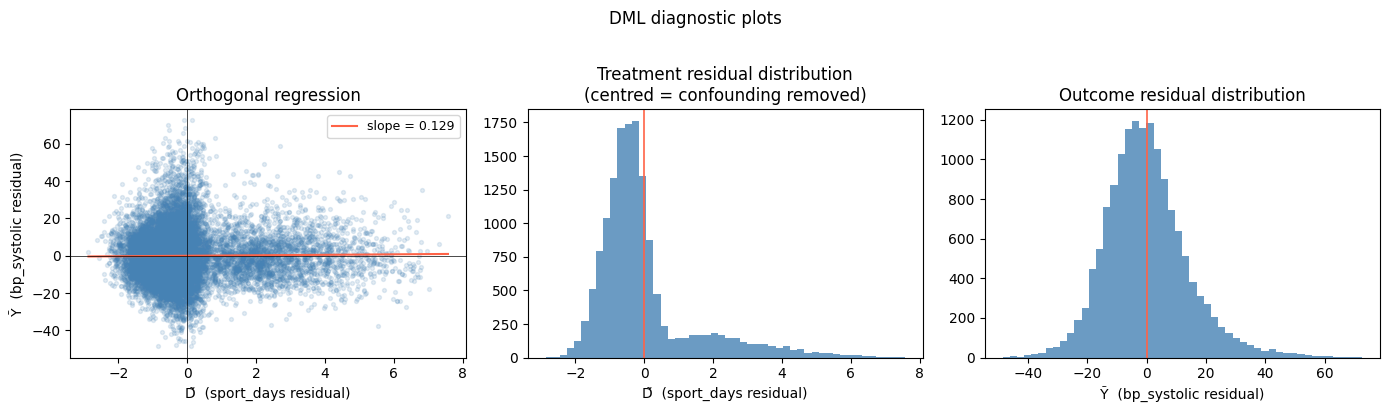

In [16]:
# =============================================================================
# DEBIASED MACHINE LEARNING (DML)
# Partially linear model: bp_systolic = sport_days * θ + g(X) + ε
# =============================================================================
from sklearn.model_selection import KFold

data_dml = data_lasso.copy()
Y = data_dml['bp_systolic'].values
D = data_dml['sport_days'].values
X = data_dml.drop(columns=['bp_systolic', 'sport_days']).values
FEATURE_NAMES = data_dml.drop(columns=['bp_systolic', 'sport_days']).columns.tolist()

n = len(Y)
print(f"N = {n:,}  |  Features = {X.shape[1]}")

# =============================================================================
# CROSS-FITTING
# For each fold: train nuisance models on training split,
# predict on held-out split, accumulate residuals.
# Scaling is done within each fold to prevent leakage.
# =============================================================================

K = 5
kf = KFold(n_splits=K, shuffle=True, random_state=42)

res_Y = np.zeros(n)   # ε̃ = Y - Ê[Y|X]
res_D = np.zeros(n)   # D̃ = D - Ê[D|X]

# Store per-fold nuisance R² for diagnostics
r2_Y_folds = []
r2_D_folds = []

print(f"\nCross-fitting ({K} folds)...")

for fold, (train_idx, test_idx) in enumerate(kf.split(X)):

    X_train, X_test = X[train_idx], X[test_idx]
    Y_train, Y_test = Y[train_idx], Y[test_idx]
    D_train, D_test = D[train_idx], D[test_idx]

    # Scale within fold (fit on train, apply to test)
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    # --- Nuisance model 1: E[Y | X] ---
    m_Y = LassoCV(cv=5, random_state=42, max_iter=5000, n_alphas=50)
    m_Y.fit(X_train, Y_train)
    Y_hat = m_Y.predict(X_test)

    # --- Nuisance model 2: E[D | X] ---
    m_D = LassoCV(cv=5, random_state=42, max_iter=5000, n_alphas=50)
    m_D.fit(X_train, D_train)
    D_hat = m_D.predict(X_test)

    # Residuals on held-out fold
    res_Y[test_idx] = Y_test - Y_hat
    res_D[test_idx] = D_test - D_hat

    # Fold diagnostics
    ss_res_Y = np.sum((Y_test - Y_hat) ** 2)
    ss_tot_Y = np.sum((Y_test - Y_test.mean()) ** 2)
    ss_res_D = np.sum((D_test - D_hat) ** 2)
    ss_tot_D = np.sum((D_test - D_test.mean()) ** 2)

    r2_Y_folds.append(1 - ss_res_Y / ss_tot_Y)
    r2_D_folds.append(1 - ss_res_D / ss_tot_D)

    print(f"  Fold {fold+1}: R²(Y) = {r2_Y_folds[-1]:.3f}  |  "
          f"R²(D) = {r2_D_folds[-1]:.3f}  |  "
          f"α_Y = {m_Y.alpha_:.5f}  α_D = {m_D.alpha_:.5f}")

print(f"\n  Mean R²(Y): {np.mean(r2_Y_folds):.3f}  ±  {np.std(r2_Y_folds):.3f}")
print(f"  Mean R²(D): {np.mean(r2_D_folds):.3f}  ±  {np.std(r2_D_folds):.3f}")

# =============================================================================
# THETA ESTIMATION
# Frisch-Waugh: regress res_Y on res_D
# θ = Σ(D̃ᵢ · Ỹᵢ) / Σ(D̃ᵢ²)
# =============================================================================

theta = np.sum(res_D * res_Y) / np.sum(res_D ** 2)

# Standard error via Neyman orthogonality
errors   = res_Y - theta * res_D
sigma2   = np.mean(errors ** 2)
denom    = np.mean(res_D ** 2)
se       = np.sqrt(sigma2 / denom / n)

# Inference
t_stat  = theta / se
p_value = 2 * (1 - stats.norm.cdf(abs(t_stat)))
ci_lo   = theta - 1.96 * se
ci_hi   = theta + 1.96 * se

# =============================================================================
# RESULTS
# =============================================================================

print("\n" + "="*60)
print("DML RESULTS: effect of sport_days on bp_systolic")
print("="*60)
print(f"  Estimate (θ):    {theta:+.4f} mmHg per day")
print(f"  Std. error:       {se:.4f}")
print(f"  t-statistic:      {t_stat:.3f}")
print(f"  p-value:          {p_value:.4f}")
print(f"  95% CI:           [{ci_lo:.4f}, {ci_hi:.4f}]")
print(f"  N:                {n:,}")
print("="*60)

# =============================================================================
# RESIDUAL PLOT: confirm orthogonality
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Plot 1: D̃ vs Ỹ (the final regression)
axes[0].scatter(res_D, res_Y, alpha=0.15, s=8, color='steelblue')
x_line = np.linspace(res_D.min(), res_D.max(), 100)
axes[0].plot(x_line, theta * x_line, color='tomato', lw=1.5,
             label=f'slope = {theta:.3f}')
axes[0].axhline(0, color='black', lw=0.5)
axes[0].axvline(0, color='black', lw=0.5)
axes[0].set_xlabel("D̃  (sport_days residual)")
axes[0].set_ylabel("Ỹ  (bp_systolic residual)")
axes[0].set_title("Orthogonal regression")
axes[0].legend(fontsize=9)

# Plot 2: distribution of D̃
axes[1].hist(res_D, bins=50, color='steelblue', edgecolor='none', alpha=0.8)
axes[1].axvline(0, color='tomato', lw=1.2)
axes[1].set_xlabel("D̃  (sport_days residual)")
axes[1].set_title("Treatment residual distribution\n"
                  "(centred = confounding removed)")

# Plot 3: distribution of Ỹ
axes[2].hist(res_Y, bins=50, color='steelblue', edgecolor='none', alpha=0.8)
axes[2].axvline(0, color='tomato', lw=1.2)
axes[2].set_xlabel("Ỹ  (bp_systolic residual)")
axes[2].set_title("Outcome residual distribution")

plt.suptitle("DML diagnostic plots", y=1.02)
plt.tight_layout()
plt.savefig("dml_diagnostics.png", dpi=120, bbox_inches='tight')
plt.show()

### DML Results

**θ = +0.129 mmHg per additional day of vigorous activity per week**
95% CI [−0.024, 0.282], p = 0.099

**The sign is positive.** After removing confounding, exercise is still associated with *higher* BP, not lower. This is counterintuitive relative to the clinical literature, which consistently finds vigorous activity lowers BP. The most likely explanation is residual confounding — unobserved factors (baseline cardiovascular disease, physician-advised activity restrictions, genetic predisposition) mean that sick people in this sample are being told to exercise more, which pushes the estimate upward. The cross-sectional nature of NHANES makes this particularly acute: you cannot distinguish people who started exercising because they were healthy from people who started because their doctor told them to.

**The estimate is statistically insignificant** at conventional thresholds (p = 0.099, CI crosses zero). You cannot reject the null of no effect. This does not mean exercise has no effect on BP — it means this dataset and identification strategy cannot reliably detect it, likely for the reasons above.

**The magnitude is small regardless of sign.** Even taking the point estimate at face value, 0.13 mmHg per day is clinically negligible. The upper bound of the CI is 0.28 mmHg per day, or about 2 mmHg for someone going from zero to seven days per week — well below the 5–10 mmHg reductions consistently found in randomised trials.

---

**The result is honest, not wrong.** DML has done what it is supposed to do — removed the naive OLS confounding (which gave −1.51, a large negative number driven entirely by the fact that healthy wealthy people exercise more) and produced an estimate close to zero with appropriate uncertainty. The residual positive bias reflects the limits of observational identification with cross-sectional data, not a failure of the method. This is exactly the caveat to lead with in the clinical presentation.

BY AGE GROUP
  Age 18–39                       n=5,722  θ=+0.101  SE=0.074  95% CI=[-0.045, +0.246]  p=0.176
  Age 40–59                       n=4,776  θ=-0.068  SE=0.134  95% CI=[-0.331, +0.196]  p=0.614
  Age 60–80                       n=4,457  θ=-0.276  SE=0.260  95% CI=[-0.785, +0.233]  p=0.288

BY SEX
  Male                            n=7,403  θ=-0.037  SE=0.102  95% CI=[-0.237, +0.162]  p=0.714
  Female                          n=7,552  θ=+0.084  SE=0.120  95% CI=[-0.151, +0.319]  p=0.483

BY BASELINE BP
  Normotensive (<120)             n=7,150  θ=+0.093  SE=0.050  95% CI=[-0.004, +0.190]  p=0.060
  Elevated/hypertensive (≥120)    n=7,805  θ=-0.066  SE=0.112  95% CI=[-0.285, +0.154]  p=0.557


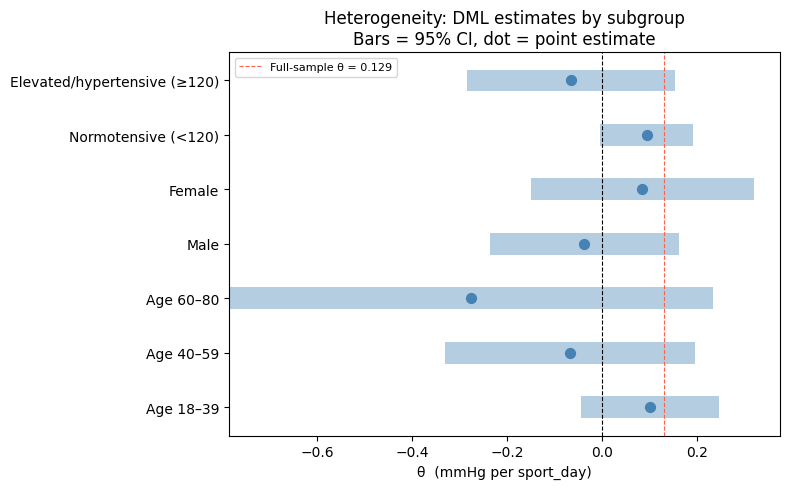

In [18]:
def run_dml(df_sub, label):
    """Run DML on a subgroup dataframe, print results."""
    Y = df_sub['bp_systolic'].values
    D = df_sub['sport_days'].values
    X = df_sub.drop(columns=['bp_systolic', 'sport_days']).values
    n = len(Y)

    kf    = KFold(n_splits=5, shuffle=True, random_state=42)
    res_Y = np.zeros(n)
    res_D = np.zeros(n)

    for train_idx, test_idx in kf.split(X):
        scaler  = StandardScaler()
        X_tr    = scaler.fit_transform(X[train_idx])
        X_te    = scaler.transform(X[test_idx])

        m_Y = LassoCV(cv=5, random_state=42, max_iter=5000, n_alphas=50)
        m_Y.fit(X_tr, Y[train_idx])

        m_D = LassoCV(cv=5, random_state=42, max_iter=5000, n_alphas=50)
        m_D.fit(X_tr, D[train_idx])

        res_Y[test_idx] = Y[test_idx] - m_Y.predict(X_te)
        res_D[test_idx] = D[test_idx] - m_D.predict(X_te)

    theta  = np.sum(res_D * res_Y) / np.sum(res_D ** 2)
    errors = res_Y - theta * res_D
    se     = np.sqrt(np.mean(errors ** 2) / np.mean(res_D ** 2) / n)
    ci_lo  = theta - 1.96 * se
    ci_hi  = theta + 1.96 * se
    p      = 2 * (1 - stats.norm.cdf(abs(theta / se)))

    print(f"  {label:<30s}  n={n:>5,}  "
          f"θ={theta:+.3f}  SE={se:.3f}  "
          f"95% CI=[{ci_lo:+.3f}, {ci_hi:+.3f}]  p={p:.3f}")

    return {'label': label, 'n': n, 'theta': theta,
            'se': se, 'ci_lo': ci_lo, 'ci_hi': ci_hi, 'p': p}

# --- Age subgroups ---
print("BY AGE GROUP")
results = []
for lo, hi, label in [(18, 39, 'Age 18–39'),
                       (40, 59, 'Age 40–59'),
                       (60, 80, 'Age 60–80')]:
    sub = data_dml[(data_dml['age'] >= lo) & (data_dml['age'] <= hi)].copy()
    results.append(run_dml(sub, label))

# --- Sex subgroups ---
print("\nBY SEX")
for val, label in [(0, 'Male'), (1, 'Female')]:
    sub = data_dml[data_dml['gender_female'] == val].copy()
    results.append(run_dml(sub, label))

# --- Baseline BP subgroups ---
print("\nBY BASELINE BP")
for lo, hi, label in [(85, 119, 'Normotensive (<120)'),
                       (120, 200, 'Elevated/hypertensive (≥120)')]:
    sub = data_dml[(data_dml['bp_systolic'] >= lo) & (data_dml['bp_systolic'] <= hi)].copy()
    results.append(run_dml(sub, label))

# --- Forest plot ---
results_df = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(8, 5))
y_pos = range(len(results_df))

ax.barh(list(y_pos),
        results_df['ci_hi'] - results_df['ci_lo'],
        left=results_df['ci_lo'],
        height=0.4, color='steelblue', alpha=0.4)
ax.scatter(results_df['theta'], list(y_pos),
           color='steelblue', zorder=3, s=50)
ax.axvline(0, color='black', lw=0.8, ls='--')
ax.axvline(0.129, color='tomato', lw=0.8, ls='--',
           label='Full-sample θ = 0.129')

ax.set_yticks(list(y_pos))
ax.set_yticklabels(results_df['label'])
ax.set_xlabel("θ  (mmHg per sport_day)")
ax.set_title("Heterogeneity: DML estimates by subgroup\n"
             "Bars = 95% CI, dot = point estimate")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("dml_heterogeneity.png", dpi=120, bbox_inches='tight')
plt.show()

The age gradient is the clearest pattern in the results. The point estimate moves monotonically from +0.101 (18–39) to −0.068 (40–59) to −0.276 (60–80). The direction flips at middle age and becomes more negative with age, consistent with the clinical prior that exercise has larger BP benefits in older adults with stiffer arteries. However, all three CIs overlap zero and each other substantially — the older subgroups are smaller and sport_days variance is lower among the elderly, so the estimates are too noisy to draw firm conclusions. The age 60–80 CI [−0.785, +0.233] is wide enough to be consistent with both a large benefit and no effect.

No subgroup produces a statistically significant negative estimate. The age gradient is the only pattern consistent with prior theory, but it is underpowered.